# chen2024 — dataset onboarding

Kernel: **chen2024 (.venv)**. Data: `data/` -> DANDI 000363, Mesoscale Activity Map dataset.

Load one session and look around.

In [1]:
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pynwb import NWBHDF5IO

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 50)

DATA = '/groups/zhang/home/zhangl5/Data-Format/manual/chen2024/data'
files = sorted(glob.glob(DATA + '/sub-*/*.nwb'))

print(len(files), 'nwb files')
files[:3]

174 nwb files


['/groups/zhang/home/zhangl5/Data-Format/manual/chen2024/data/sub-440956/sub-440956_ses-20190207T120657_behavior+ecephys+ogen.nwb',
 '/groups/zhang/home/zhangl5/Data-Format/manual/chen2024/data/sub-440956/sub-440956_ses-20190208T133600_behavior+ecephys+ogen.nwb',
 '/groups/zhang/home/zhangl5/Data-Format/manual/chen2024/data/sub-440956/sub-440956_ses-20190209T150135_behavior+ecephys+ogen.nwb']

## Open one session

`NWBHDF5IO` reads lazily — datasets stay on disk until you index into them.

In [2]:
io = NWBHDF5IO(files[0], mode='r', load_namespaces=True)
nwb = io.read()
nwb

Data type,float64
Shape,"(395,)"
Array size,3.09 KiB
Chunk shape,None
Compression,None
Compression opts,None
Uncompressed size (bytes),3160
Compressed size (bytes),3160
Compression ratio,1.0
Data type,float64
Shape,"(395,)"


## Session metadata

In [3]:
# use this for unique subject_id
nwb.subject.subject_id

'440956'

In [4]:
print('identifier         :', nwb.identifier)
print('session_start_time :', nwb.session_start_time)
print('subject_id         :', nwb.subject.subject_id)
print('experiment_descr.  :', nwb.experiment_description)
print('institution        :', nwb.institution)
print()
print('acquisition :', list(nwb.acquisition))
print('intervals   :', list(nwb.intervals))
print('devices     :', list(nwb.devices))
print('ogen sites  :', list(nwb.ogen_sites))

identifier         : SC015_20190207_120657_s1
session_start_time : 2019-02-07 12:06:57-06:00
subject_id         : 440956
experiment_descr.  : high tone vs. low tone
institution        : Janelia Research Campus

acquisition : ['BehavioralEvents', 'BehavioralTimeSeries']
intervals   : ['trials']
devices     : ['17131309211 (neuropixels 1.0 - 3B)', '17216703352 (neuropixels 1.0 - 3B)', '18005117122 (neuropixels 1.0 - 3B)', '18005118502 (neuropixels 1.0 - 3B)', 'OBIS470']
ogen sites  : ['OBIS470_4', 'OBIS470_6']


## Trials

In [5]:
trials = nwb.trials.to_dataframe()
print(trials.shape)
trials.head(10)

(368, 14)


,start_time,stop_time,trial,photostim_onset,photostim_power,photostim_duration,trial_uid,task,task_protocol,trial_instruction,early_lick,outcome,auto_water,free_water
id,,,,,,,,,,,,,,
0,0.0000,4.8615,1,N/A,N/A,N/A,1,audio delay,1,right,no early,ignore,0,0
1,6.6536,12.2911,2,N/A,N/A,N/A,2,audio delay,1,right,early,ignore,0,0
2,14.0799,20.0728,3,N/A,N/A,N/A,3,audio delay,1,right,no early,hit,0,0
3,24.0631,29.1689,4,N/A,N/A,N/A,4,audio delay,1,right,no early,hit,0,0
4,31.1768,37.0372,5,N/A,N/A,N/A,5,audio delay,1,right,early,ignore,0,0
5,38.8261,44.7050,6,N/A,N/A,N/A,6,audio delay,1,right,early,ignore,0,0
6,46.4960,51.5081,7,N/A,N/A,N/A,7,audio delay,1,right,no early,ignore,0,0
7,53.3019,58.3462,8,N/A,N/A,N/A,8,audio delay,1,right,no early,ignore,0,0
8,60.1410,65.1748,9,N/A,N/A,N/A,9,audio delay,1,right,no early,hit,0,0


## Units

In [6]:
print('n units:', len(nwb.units.id))
print()
for c in nwb.units.colnames:
    print('   ', c)

n units: 1952

    unit
    sampling_rate
    unit_quality
    unit_posx
    unit_posy
    unit_amp
    unit_snr
    isi_violation
    avg_firing_rate
    drift_metric
    left_trials_drift_metric
    right_trials_drift_metric
    presence_ratio
    amplitude_cutoff
    isolation_distance
    l_ratio
    d_prime
    nn_hit_rate
    nn_miss_rate
    silhouette_score
    max_drift
    cumulative_drift
    duration
    halfwidth
    pt_ratio
    repolarization_slope
    recovery_slope
    spread
    velocity_above
    velocity_below
    classification
    anno_name
    is_good_trials
    spike_times
    obs_intervals
    electrodes
    electrode_group
    waveform_mean
    waveform_sd


## Behaviour: what is in `acquisition`

In [7]:
for name, mod in nwb.acquisition.items():
    print(name)
    for k, ts in mod.time_series.items():
        print(f'    {k:<30} data{ts.data.shape}')

BehavioralEvents
    delay_start_times              data(395,)
    delay_stop_times               data(395,)
    go_start_times                 data(368,)
    go_stop_times                  data(368,)
    left_lick_times                data(1262,)
    photostim_start_times          data(78,)
    photostim_stop_times           data(78,)
    presample_start_times          data(368,)
    presample_stop_times           data(368,)
    right_lick_times               data(971,)
    sample_start_times             data(405,)
    sample_stop_times              data(405,)
    trialend_start_times           data(368,)
    trialend_stop_times            data(368,)
BehavioralTimeSeries
    Camera0_side_JawTracking       data(680500, 3)
    Camera0_side_NoseTracking      data(680500, 3)
    Camera0_side_TongueTracking    data(680500, 3)


## Behaviour variables — trial event times

Everything in the NWB is on one **session-absolute** clock (seconds from `session_start_time`).

* `go_start_times` — the alignment event. One entry per trial here (368 events / 368 trials).
* `sample_start_times` — the tone onset. **More entries than trials** (405), because an early lick
  aborts the trial and the sample is re-presented. So we can't index it by trial; for each go cue we
  take the *last* sample onset before it, which is the sample that actually led to that go cue.


In [8]:
def trial_events(nwb):
    """Per-trial event times (session-absolute seconds), one row per trial."""
    be = nwb.acquisition['BehavioralEvents'].time_series
    tr = nwb.trials.to_dataframe()

    go = np.asarray(be['go_start_times'].timestamps)
    sample = np.asarray(be['sample_start_times'].timestamps)
    delay = np.asarray(be['delay_start_times'].timestamps)

    assert len(go) == len(tr), f'{len(go)} go cues vs {len(tr)} trials'

    # last sample / delay onset strictly before each go cue
    i = np.searchsorted(sample, go, side='left') - 1
    j = np.searchsorted(delay, go, side='left') - 1
    assert (i >= 0).all() and (j >= 0).all(), 'a go cue precedes every sample onset'

    ev = pd.DataFrame({
        'trial_start': tr['start_time'].values,
        'trial_stop': tr['stop_time'].values,
        'tone_onset': sample[i],
        'delay_onset': delay[j],
        'go': go,
    })

    # photostim: trials table stores onset/duration as strings relative to trial_start
    on = tr['photostim_onset'].values
    dur = tr['photostim_duration'].values
    has = on != 'N/A'
    ev['stim_on'] = np.where(has, ev['trial_start'] + np.where(has, on, 0).astype(float), np.nan)
    ev['stim_off'] = ev['stim_on'] + np.where(has, np.where(has, dur, 0).astype(float), np.nan)
    return ev

ev = trial_events(nwb)
ev.head(8)

,trial_start,trial_stop,tone_onset,delay_onset,go,stim_on,stim_off
0,0.0000,4.8615,1.2115,1.8615,3.0615,NaN,NaN
1,6.6536,12.2911,8.6411,9.2911,10.4911,NaN,NaN
2,14.0799,20.0728,15.4514,16.1014,17.3014,NaN,NaN
3,24.0631,29.1689,25.3602,26.0102,27.2102,NaN,NaN
4,31.1768,37.0372,33.3872,34.0372,35.2372,NaN,NaN
5,38.8261,44.7050,41.0550,41.7050,42.9050,NaN,NaN
6,46.4960,51.5081,47.8581,48.5081,49.7081,NaN,NaN
7,53.3019,58.3462,54.6962,55.3462,56.5462,NaN,NaN


Sanity: the matched tone onset should land inside its own trial, i.e.
`trial_start <= tone_onset < go < trial_stop`.

In [9]:
print('tone_onset inside its trial :', ((ev.tone_onset >= ev.trial_start) & (ev.tone_onset < ev.go)).all())
print('delay_onset after tone     :', (ev.delay_onset > ev.tone_onset).all())
print()
print('go - tone_onset (s):')
print((ev.go - ev.tone_onset).round(3).value_counts().head(8))
print()
print('n trials with photostim:', ev.stim_on.notna().sum())
print('stim onset relative to go cue:', (ev.stim_on - ev.go).round(3).dropna().unique()[:8])

tone_onset inside its trial : True
delay_onset after tone     : True

go - tone_onset (s):
1.850    359
2.626      1
1.987      1
3.722      1
2.008      1
2.593      1
2.902      1
4.247      1
Name: count, dtype: int64

n trials with photostim: 78
stim onset relative to go cue: [-1.2   -1.199 -2.253]


### Why some trials have a different go-minus-tone lag

97.6% of trials sit at 1.85 s, but a handful go out to 4.25 s. All of them are `early_lick == 'early'`.

Looking at the raw events: an early lick **restarts the delay**, not the sample — a trial can carry
one sample onset but four or eight delay onsets, and the go cue always follows 1.2 s after the *final*
delay onset. Sometimes the sample is re-presented too. Either way "last sample onset before the go
cue" picks the tone the animal actually heard, and the lag stretches accordingly.

In [10]:
n_sample = np.array([((sam >= a) & (sam < g)).sum()
                     for sam, a, g in [(np.asarray(nwb.acquisition['BehavioralEvents']
                                                   .time_series['sample_start_times'].timestamps), a, g)
                                       for a, g in zip(ev.trial_start, ev.go)]])
lag = (ev.go - ev.tone_onset).values

print('sample onsets per trial, by early_lick:')
print(pd.crosstab(trials.early_lick.values, n_sample))
print()
print('trials with lag != 1.85:', (np.abs(lag - 1.85) > 0.01).sum(),
      '| all early_lick?', (trials.early_lick.values[np.abs(lag - 1.85) > 0.01] == 'early').all())

# one example, in full
sam = np.asarray(nwb.acquisition['BehavioralEvents'].time_series['sample_start_times'].timestamps)
dly = np.asarray(nwb.acquisition['BehavioralEvents'].time_series['delay_start_times'].timestamps)
t = np.flatnonzero(np.abs(lag - 1.85) > 0.01)[0]
a, g = ev.trial_start[t], ev.go[t]
print(f'\ntrial {t} ({trials.early_lick.values[t]}, {trials.outcome.values[t]}) — times re go cue:')
print('   sample onsets:', np.round(sam[(sam >= a) & (sam < g)] - g, 3))
print('   delay onsets :', np.round(dly[(dly >= a) & (dly < g)] - g, 3))

sample onsets per trial, by early_lick:
col_0      1   2   3   4   6   12
row_0                            
early       8   2   3   1   3   1
no early  350   0   0   0   0   0

trials with lag != 1.85: 9 | all early_lick? True

trial 9 (early, ignore) — times re go cue:
   sample onsets: [-2.626]
   delay onsets : [-1.976 -1.621 -1.417 -1.2  ]


### Why sample events outnumber trials too

A lick during the **sample** period aborts and re-presents the tone, the same way a lick during the
delay restarts the delay. Both push the go cue later.

| stream | events | = trials + restarts |
|---|---|---|
| presample | 368 | 368 + 0 (never restarts) |
| sample | 405 | 368 + 37 |
| delay | 395 | 368 + 27 |
| go | 368 | one per trial |

Note the two streams log aborted periods **differently**: `sample_stop` is always `sample_start + 0.65`
even when the sample was cut short, so sample windows *overlap* on restart trials. `delay_stop` is
genuinely truncated. Only `sample_start` should be trusted.

In [11]:
bev = nwb.acquisition['BehavioralEvents'].time_series
sam = np.asarray(bev['sample_start_times'].timestamps)
sam_stop = np.asarray(bev['sample_stop_times'].timestamps)
dly = np.asarray(bev['delay_start_times'].timestamps)
dly_stop = np.asarray(bev['delay_stop_times'].timestamps)
licks = np.sort(np.concatenate([np.asarray(bev['left_lick_times'].timestamps),
                                np.asarray(bev['right_lick_times'].timestamps)]))

# every sample event that is NOT the last one in its trial
tr_of_sam = np.searchsorted(ev.trial_start.values, sam, side='right') - 1
aborted = np.zeros(len(sam), bool)
for t in np.unique(tr_of_sam):
    k = np.flatnonzero(tr_of_sam == t)
    aborted[k[:-1]] = True

n_lick_inside = np.array([((licks >= sam[k]) & (licks <= sam_stop[k])).sum()
                          for k in np.flatnonzero(aborted)])
print('aborted sample events          :', aborted.sum())
print('  with a lick inside            :', (n_lick_inside > 0).sum())
print('sample durations (all)          :', np.unique(np.round(sam_stop - sam, 3)))
print('delay durations (value_counts)  :')
print(pd.Series(np.round(dly_stop - dly, 3)).value_counts().head(4).to_string())

aborted sample events          : 37
  with a lick inside            : 37
sample durations (all)          : [0.65]
delay durations (value_counts)  :
1.200    368
0.205      2
0.355      1
0.204      1


In [12]:
def walk_trial(t):
    """Print every event in one trial, in order, relative to its go cue."""
    a, g = ev.trial_start[t], ev.go[t] + 0.1
    rows = [(v - ev.go[t], nm)
            for nm, arr in [('presample', np.asarray(bev['presample_start_times'].timestamps)),
                            ('sample', sam), ('delay', dly), ('go', ev.go.values)]
            for v in arr[(arr >= a) & (arr <= g)]]
    rows += [(v - ev.go[t], 'LICK') for v in licks[(licks >= a) & (licks <= g)]]
    print(f'trial {t}  early_lick={trials.early_lick.values[t]}  '
          f'outcome={trials.outcome.values[t]}   (s re go cue)')
    for v, nm in sorted(rows):
        print(f'   {v:>8.3f}  {nm}')


walk_trial(int(pd.Series(tr_of_sam).value_counts().idxmax()))

trial 33  early_lick=early  outcome=ignore   (s re go cue)
     -5.058  presample
     -4.248  sample
     -3.917  LICK
     -3.817  sample
     -3.754  LICK
     -3.654  sample
     -3.606  LICK
     -3.506  sample
     -3.442  LICK
     -3.342  sample
     -3.292  LICK
     -3.192  sample
     -3.142  LICK
     -3.042  sample
     -2.998  LICK
     -2.898  sample
     -2.837  LICK
     -2.737  sample
     -2.314  LICK
     -2.214  sample
     -2.153  LICK
     -2.052  sample
     -1.950  LICK
     -1.850  sample
     -1.200  delay
      0.000  go


### Photostim is locked to the delay, not the go cue

Nearly all stim onsets sit at -1.2 s re go = delay onset. The one outlier at -2.25 s is an early-lick
trial whose delay restarted after the laser had already fired. Reading absolute event times handles
this for free — assuming a fixed offset from the go cue would not.

In [13]:
rel = (ev.stim_on - ev.go).round(3)
print(rel.value_counts().to_string())

t = rel.idxmin()
print(f'\noutlier trial {t}: early={trials.early_lick.values[t]}, '
      f'stim re go={rel[t]:.3f}, tone re go={(ev.tone_onset - ev.go)[t]:.3f}')
print('   delay onsets re go:', np.round(dly[(dly >= ev.trial_start[t]) & (dly < ev.go[t])] - ev.go[t], 3))

-1.200    73
-1.199     4
-2.253     1

outlier trial 204: early=early, stim re go=-2.253, tone re go=-2.902
   delay onsets re go: [-2.252 -1.513 -1.361 -1.2  ]


## Time bins

Align on the go cue, **-2.5 s to +1.5 s**, **50 ms** bins -> 4.0 / 0.05 = **80 bins**.

`edges` are relative to the go cue; `centers` is what we use as the time axis. The same grid is used
for the neural data downstream, so inputs and firing rates share bins exactly.

In [14]:
T_START, T_STOP, BIN = -2.5, 1.5, 0.05

edges = np.arange(T_START, T_STOP + BIN / 2, BIN)      # 81 edges, relative to go cue
centers = edges[:-1] + BIN / 2                          # 80 bin centers
n_bins = len(centers)

print('n edges  :', len(edges))
print('n bins   :', n_bins)
print('centers  :', centers[:4], '...', centers[-3:])

n edges  : 81
n bins   : 80
centers  : [-2.475 -2.425 -2.375 -2.325] ... [1.375 1.425 1.475]


## Input 1 — time from tone onset

The bins are laid out around the go cue, but the *value* in each bin is the time since that trial's
tone onset:

```
time_from_tone[trial, b] = (go[trial] + centers[b]) - tone_onset[trial]
                         = centers[b] + (go[trial] - tone_onset[trial])
```

so each trial is the same ramp shifted by its own go-minus-tone lag. Trials with a longer delay get
a larger offset.

In [15]:
def time_from_tone(ev, centers):
    """(n_trials, n_bins) seconds since that trial's tone onset."""
    lag = (ev['go'] - ev['tone_onset']).values          # (n_trials,)
    return centers[None, :] + lag[:, None]


tft = time_from_tone(ev, centers)
print('shape        :', tft.shape)
print('overall range: [%.3f, %.3f] s' % (tft.min(), tft.max()))
print()
print('trial 0 (go - tone = %.3f s):' % (ev.go[0] - ev.tone_onset[0]))
print('   ', tft[0, :5].round(3), '...', tft[0, -3:].round(3))

shape        : (368, 80)
overall range: [-0.625, 5.722] s

trial 0 (go - tone = 1.850 s):
    [-0.625 -0.575 -0.525 -0.475 -0.425] ... [3.225 3.275 3.325]


## Input 2 — photostimulation on/off

Binary per bin: a bin is on if its **centre** falls inside `[stim_on, stim_off)`.

(An interval-overlap rule looks safer but isn't: the recorded onset sits ~0.1 ms off the bin grid, so
overlap flags an 11th bin on the strength of 0.1 ms. Centre-inside gives exactly 10 bins = 0.500 s,
matching the pulse duration. Every pulse is 0.5 s and every bin 0.05 s, so a pulse always spans ~10
centres — it can never slip between them.)

In [16]:
def photostim_on(ev, centers):
    """(n_trials, n_bins) binary — 1 where the bin centre is inside the stim interval."""
    on = (ev['stim_on'] - ev['go']).values[:, None]      # relative to go cue
    off = (ev['stim_off'] - ev['go']).values[:, None]
    # non-stim trials carry NaN; every comparison against NaN is False, so they stay 0
    return ((centers[None, :] >= on) & (centers[None, :] < off)).astype(np.int8)


stim = photostim_on(ev, centers)
print('shape           :', stim.shape)
print('trials with stim:', (stim.sum(1) > 0).sum(), '(trials table says %d)' % ev.stim_on.notna().sum())
print('bins on per stim trial:', np.unique(stim.sum(1)[stim.sum(1) > 0]),
      '-> %.3f s' % (np.unique(stim.sum(1)[stim.sum(1) > 0])[0] * BIN))

i = np.flatnonzero(stim.sum(1) > 0)[0]
print()
print('first stim trial (idx %d), bins that are on:' % i)
print('   centers', centers[stim[i] > 0].round(3))

shape           : (368, 80)
trials with stim: 78 (trials table says 78)
bins on per stim trial: [10] -> 0.500 s

first stim trial (idx 67), bins that are on:
   centers [-1.175 -1.125 -1.075 -1.025 -0.975 -0.925 -0.875 -0.825 -0.775 -0.725]


## What it looks like

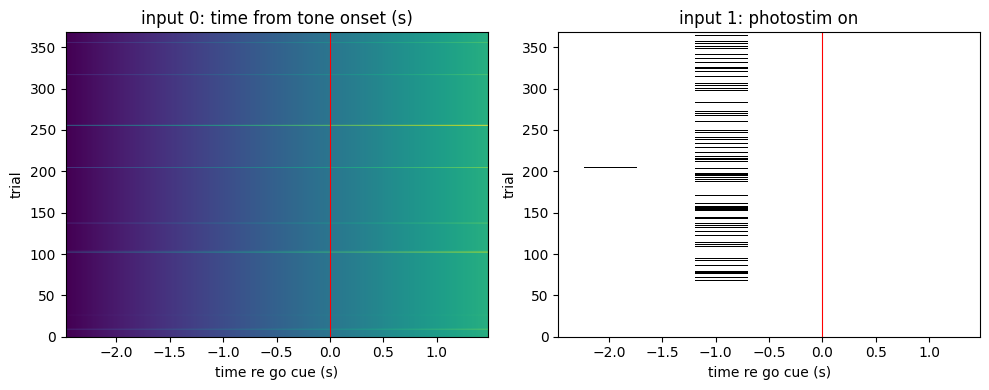

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].imshow(tft, aspect='auto', origin='lower',
             extent=[centers[0], centers[-1], 0, len(ev)], cmap='viridis')
ax[0].set(title='input 0: time from tone onset (s)', xlabel='time re go cue (s)', ylabel='trial')

ax[1].imshow(stim, aspect='auto', origin='lower', interpolation='nearest',
             extent=[centers[0], centers[-1], 0, len(ev)], cmap='Greys')
ax[1].set(title='input 1: photostim on', xlabel='time re go cue (s)', ylabel='trial')

for a in ax:
    a.axvline(0, color='r', lw=0.8)
plt.tight_layout()

### Single-trial extraction

**Inputs**, per 50 ms bin (80 bins over -2.5 s to +1.5 s around the go cue):

1. the trial's **go cue** defines the window
2. walk backwards from the go cue to the **last tone (sample) onset** -> that is time 0
3. `time_from_tone` — time from tone onset
4. `photostim` — binary, 1 where the bin centre is inside the pulse

**Outputs**, one value per trial:

5. `choice` — left 0, right 1, no lick -1. Derived from the trial type: `hit` -> the instructed side,
   `miss` -> the other side, `ignore` -> -1.
   `outcome` — ignore 0, miss 1, hit 2. `early_lick` — no 0, yes 1.

In [18]:
OUTCOME_CODE = {'ignore': 0, 'miss': 1, 'hit': 2}
EARLY_CODE = {'no early': 0, 'early': 1}
SIDE_CODE = {'left': 0, 'right': 1}      # choice -1 = no lick


def extract_trial(nwb, i, t_start=-2.5, t_stop=1.5, bin_size=0.05):
    """Decoder inputs and outputs for a single trial. Returns (outputs, bins)."""
    bev = nwb.acquisition['BehavioralEvents'].time_series
    tr = nwb.trials.to_dataframe()

    # --- 1. alignment event: this trial's go cue (session-absolute seconds) ---
    go = np.asarray(bev['go_start_times'].timestamps)[i]

    # --- 2. walk backwards to the last tone onset before the go cue -> time 0 ---
    sample = np.asarray(bev['sample_start_times'].timestamps)
    tone = sample[sample < go][-1]

    # --- 3. bin grid, relative to the go cue ---
    edges = np.arange(t_start, t_stop + bin_size / 2, bin_size)
    centers = edges[:-1] + bin_size / 2

    # --- 4. input 0: time from tone onset ---
    time_from_tone = centers + (go - tone)

    # --- 5. input 1: photostim on/off (bin is on if its centre is inside the pulse) ---
    onset, dur = tr['photostim_onset'].iloc[i], tr['photostim_duration'].iloc[i]
    stim = np.zeros(len(centers), dtype=np.int8)
    if onset != 'N/A':
        on = tr['start_time'].iloc[i] + float(onset) - go      # re go cue
        stim[(centers >= on) & (centers < on + float(dur))] = 1

    # --- 6. outputs ---
    outcome = tr['outcome'].iloc[i]
    side = SIDE_CODE[tr['trial_instruction'].iloc[i]]
    if outcome == 'ignore':
        choice = -1               # never licked
    elif outcome == 'hit':
        choice = side             # licked the instructed side
    else:                         # miss -> licked the other side
        choice = 1 - side

    outputs = {
        'choice': choice,
        'outcome': OUTCOME_CODE[outcome],
        'early_lick': EARLY_CODE[tr['early_lick'].iloc[i]],
    }

    bins = pd.DataFrame({
        'bin': np.arange(len(centers)),
        't_re_go': centers,
        'time_from_tone': time_from_tone,
        'photostim': stim,
    })
    return outputs, bins

### Check the coding over the whole session

Run every trial through `extract_trial` and tabulate the outputs against the raw trials table.

In [19]:
coded = pd.DataFrame([extract_trial(nwb, i)[0] for i in range(len(trials))])
coded['instruction'] = trials['trial_instruction'].values
coded['raw_outcome'] = trials['outcome'].values
coded['raw_early'] = trials['early_lick'].values

print('choice, by (instruction, outcome):')
print(pd.crosstab([coded.instruction, coded.raw_outcome], coded.choice).to_string())
print()
print('outcome    :', coded.groupby('raw_outcome').outcome.unique().to_dict())
print('early_lick :', coded.groupby('raw_early').early_lick.unique().to_dict())
print()
for c in ['choice', 'outcome', 'early_lick']:
    print(f'{c:<11}', coded[c].value_counts().sort_index().to_dict())

choice, by (instruction, outcome):
choice                   -1   0   1
instruction raw_outcome            
left        hit           0  76   0
            ignore        9   0   0
            miss          0   0  55
right       hit           0   0  85
            ignore       63   0   0
            miss          0  80   0

outcome    : {'hit': array([2]), 'ignore': array([0]), 'miss': array([1])}
early_lick : {'early': array([1]), 'no early': array([0])}

choice      {-1: 72, 0: 156, 1: 140}
outcome     {0: 72, 1: 135, 2: 161}
early_lick  {0: 350, 1: 18}


#### Tongue tracking

Side-camera DeepLabCut markers, in `acquisition/BehavioralTimeSeries`.

In [20]:
tongue = nwb.acquisition['BehavioralTimeSeries'].time_series['Camera0_side_TongueTracking']

print(tongue.description)
print('data      :', tongue.data.shape, tongue.data.dtype)
print('timestamps:', tongue.timestamps.shape)

xyc = tongue.data[:]          # (n_frames, 3) = tongue_x, tongue_y, tongue_likelihood
t_cam = tongue.timestamps[:]  # seconds

Time series for TongueTracking position: ('tongue_x', 'tongue_y', 'tongue_likelihood')
data      : (680500, 3) float64
timestamps: (680500,)


### Is the camera clock the same clock as the trials table?

Frames come in one contiguous run per trial. If the timestamps are on the session clock, the start of
each run should land on `trials.start_time`.

In [21]:
dt = np.diff(t_cam)
print('frame dt          :', np.unique(dt.round(4))[:4], '... (%.1f Hz)' % (1 / np.median(dt)))

runs = np.flatnonzero(dt > 0.005)                       # breaks between trials
run_starts = np.concatenate([[t_cam[0]], t_cam[runs + 1]])

print('n runs            :', len(run_starts), '| n trials:', len(trials))
print('max |run start - trials.start_time| :', np.abs(run_starts - trials.start_time.values).max())
print()
print('camera spans      : %.1f .. %.1f s' % (t_cam[0], t_cam[-1]))
print('trials span       : %.1f .. %.1f s' % (trials.start_time.iloc[0], trials.stop_time.iloc[-1]))

frame dt          : [0.0034 0.2897 0.2917 0.2919] ... (294.1 Hz)
n runs            : 368 | n trials: 368
max |run start - trials.start_time| : 0.0

camera spans      : 0.0 .. 2493.3 s
trials span       : 0.0 .. 2491.8 s


### Pull the tongue trace for one trial

In [22]:
def tongue_trial(i, t_start=-2.5, t_stop=1.5):
    """Tongue markers in one trial's window. Returns (t re go cue, x, y, likelihood)."""
    go = np.asarray(nwb.acquisition['BehavioralEvents'].time_series['go_start_times'].timestamps)[i]
    m = (t_cam >= go + t_start) & (t_cam < go + t_stop)
    return t_cam[m] - go, xyc[m, 0], xyc[m, 1], xyc[m, 2]


t, x, y, c = tongue_trial(20)
print('n frames in window:', len(t))
print('t range           : %.3f .. %.3f' % (t[0], t[-1]))
print('likelihood        : frac > 0.5 = %.3f' % (c > 0.5).mean())
print('y                 : %.1f .. %.1f' % (y.min(), y.max()))

n frames in window: 1177
t range           : -2.500 .. 1.499
likelihood        : frac > 0.5 = 0.045
y                 : -1.4 .. 298.9


### Sample trials: tongue y and likelihood over `[go, go + 1.5]`

One column per trial. Top row is `tongue_y`, bottom row is `tongue_likelihood`; the dashed line marks
likelihood 0.5. Shaded spans are where likelihood > 0.5.

trials: [188 233 311]


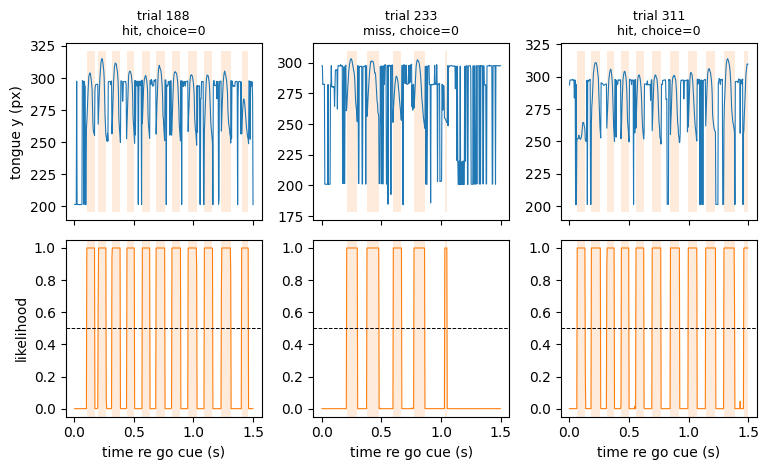

In [23]:
def plot_tongue_trials(trial_ids, t_start=0.0, t_stop=1.5, thr=0.5):
    n = len(trial_ids)
    fig, ax = plt.subplots(2, n, figsize=(2.6 * n, 4.8), sharex=True, squeeze=False)

    for k, i in enumerate(trial_ids):
        t, x, y, c = tongue_trial(i, t_start, t_stop)
        out, _ = extract_trial(nwb, i)
        vis = c > thr

        ax[0, k].plot(t, y, lw=0.8, color='C0')
        ax[0, k].set_title(f'trial {i}\n{trials.outcome.iloc[i]}, choice={out["choice"]}', fontsize=9)
        ax[1, k].plot(t, c, lw=0.8, color='C1')
        ax[1, k].axhline(thr, color='k', ls='--', lw=0.7)
        ax[1, k].set_ylim(-0.05, 1.05)
        ax[1, k].set_xlabel('time re go cue (s)')

        # shade the frames where the tongue is actually visible
        for a in ax[:, k]:
            a.fill_between(t, *a.get_ylim(), where=vis, color='C1', alpha=0.15, lw=0)

    ax[0, 0].set_ylabel('tongue y (px)')
    ax[1, 0].set_ylabel('likelihood')
    plt.tight_layout()
    return fig


rng = np.random.default_rng(0)
N = 3
sel = np.sort(rng.choice(len(trials), N, replace=False))
print('trials:', sel)
plot_tongue_trials(sel);

---

### Tongue y -> 4 classes

1. **per session**: mask `likelihood < 0.5` to NaN, average the survivors into 50 ms bins across the
   whole session, take the 40th and 60th percentiles **of those bin means** -> two edges
2. **per trial**: window in the global clock, same masking
3. **bin**: mean of the non-NaN y within each 50 ms bin
4. **discretise**: `-1` no valid frame in the bin, `0` < p40, `1` p40..p60, `2` > p60

Thresholds come from binned means rather than raw frames so that the edges are defined on the same
quantity being discretised.

In [24]:
def tongue_session(nwb, thr=0.5, q=(40, 60), bin_size=0.05):
    """Masked session-wide tongue y, and the edges taken from 50 ms bin means."""
    ts = nwb.acquisition['BehavioralTimeSeries'].time_series['Camera0_side_TongueTracking']
    t = ts.timestamps[:]
    y = ts.data[:, 1].copy()
    y[ts.data[:, 2] < thr] = np.nan          # only real protrusions survive

    # bin the whole session on one 50 ms grid, then take percentiles of the bin means
    idx = np.floor((t - t[0]) / bin_size).astype(int)
    ok = ~np.isnan(y)
    tot = np.zeros(idx[-1] + 1)
    cnt = np.zeros(idx[-1] + 1)
    np.add.at(tot, idx[ok], y[ok])
    np.add.at(cnt, idx[ok], 1)
    binned = np.where(cnt > 0, tot / np.maximum(cnt, 1), np.nan)

    return t, y, np.nanpercentile(binned, q)


def tongue_binned(t_cam, y_masked, go, edges, t_start=-2.5, t_stop=1.5, bin_size=0.05):
    """One trial: (centers, mean y per bin, n valid frames per bin, class per bin).

    class is -1 (not visible) / 0 / 1 / 2.
    """
    centers = np.arange(t_start, t_stop, bin_size) + bin_size / 2
    n = len(centers)

    rel = t_cam - go
    m = (rel >= t_start) & (rel < t_stop)
    idx = np.floor((rel[m] - t_start) / bin_size).astype(int)
    y = y_masked[m]

    ok = ~np.isnan(y)
    tot = np.zeros(n)
    cnt = np.zeros(n)
    np.add.at(tot, idx[ok], y[ok])
    np.add.at(cnt, idx[ok], 1)

    mean_y = np.where(cnt > 0, tot / np.maximum(cnt, 1), np.nan)
    cls = np.where(np.isnan(mean_y), -1, np.digitize(mean_y, edges))
    return centers, mean_y, cnt.astype(int), cls.astype(int)


t_cam, y_masked, edges = tongue_session(nwb)
print('valid frames (likelihood >= 0.5): %.3f of %d' % (np.mean(~np.isnan(y_masked)), len(y_masked)))
print('session edges  p40 = %.2f   p60 = %.2f' % tuple(edges))

valid frames (likelihood >= 0.5): 0.106 of 680500
session edges  p40 = 269.81   p60 = 280.09


A single trial, bin by bin.

In [25]:
go_all = np.asarray(nwb.acquisition['BehavioralEvents'].time_series['go_start_times'].timestamps)

i = 186
centers, mean_y, cnt, cls = tongue_binned(t_cam, y_masked, go_all[i], edges)
out = pd.DataFrame({'t_re_go': centers, 'n_valid': cnt, 'mean_y': mean_y, 'class': cls})

print(f'trial {i}: {trials.outcome.iloc[i]}')
print('bins with no valid frame: %d / %d' % ((cls < 0).sum(), len(cls)))
print()
print(out[out.n_valid > 0].head(12).to_string(index=False, na_rep='nan'))

trial 186: hit
bins with no valid frame: 54 / 80

 t_re_go  n_valid     mean_y  class
  -2.125        2 256.129337      0
  -2.075       10 255.517767      0
   0.125       14 277.710280      1
   0.175       15 270.161718      1
   0.225       14 270.647119      1
   0.275        5 273.509597      1
   0.325       15 312.477375      2
   0.375       15 305.638807      2
   0.425        5 266.320892      0
   0.475       10 298.660537      2
   0.525       15 317.428580      2
   0.575        4 275.840539      1


How often is a bin empty, across the whole session?

bins total : 29440
class distribution over ALL bins:
   {-1: 0.794, 0: 0.075, 1: 0.041, 2: 0.09}
class distribution over bins WITH data:
   {0: 0.366, 1: 0.197, 2: 0.437}

per-trial fraction of bins with data: min 0.000  median 0.237  max 0.487
trials that are entirely -1: 57 / 368


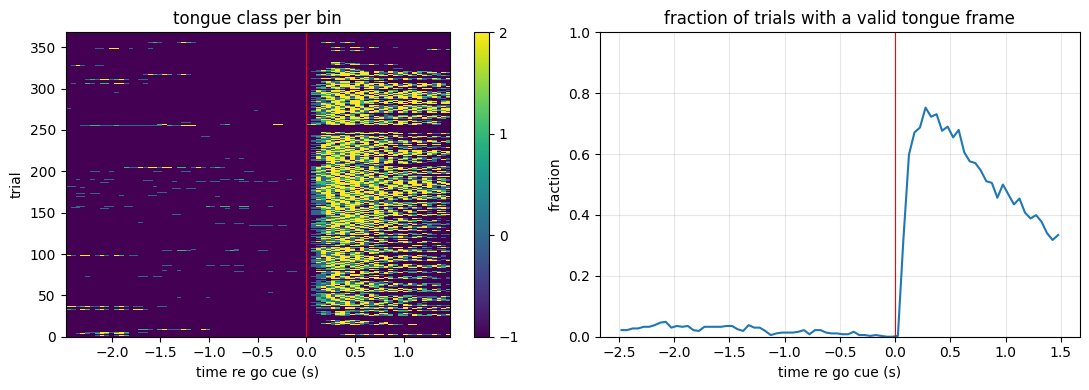

In [26]:
cls_all = np.stack([tongue_binned(t_cam, y_masked, g, edges)[3] for g in go_all])

print('bins total :', cls_all.size)
print('class distribution over ALL bins:')
print('  ', {k: round(float((cls_all == k).mean()), 3) for k in [-1, 0, 1, 2]})
print('class distribution over bins WITH data:')
v = cls_all[cls_all >= 0]
print('  ', {k: round(float((v == k).mean()), 3) for k in [0, 1, 2]})
print()
print('per-trial fraction of bins with data: min %.3f  median %.3f  max %.3f'
      % ((cls_all >= 0).mean(1).min(), np.median((cls_all >= 0).mean(1)), (cls_all >= 0).mean(1).max()))
print('trials that are entirely -1:', int(((cls_all >= 0).sum(1) == 0).sum()), '/', len(go_all))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
im = ax[0].imshow(cls_all, aspect='auto', origin='lower', interpolation='nearest',
                  extent=[centers[0], centers[-1], 0, len(go_all)], cmap='viridis', vmin=-1, vmax=2)
ax[0].set(title='tongue class per bin', xlabel='time re go cue (s)', ylabel='trial')
ax[0].axvline(0, color='r', lw=0.8)
plt.colorbar(im, ax=ax[0], ticks=[-1, 0, 1, 2])

ax[1].plot(centers, (cls_all >= 0).mean(0))
ax[1].axvline(0, color='r', lw=0.8)
ax[1].set(title='fraction of trials with a valid tongue frame',
          xlabel='time re go cue (s)', ylabel='fraction', ylim=(0, 1))
ax[1].grid(alpha=0.3)
plt.tight_layout()

## Per-trial extraction, with tongue

`-1` means "not defined" throughout — no lick for `choice`, no visible tongue for `tongue`.

The tongue discretisation edges are a **session-level** quantity, so `tongue_session(nwb)` runs once
and its outputs are passed in.

| field | kind | values |
|---|---|---|
| `time_from_tone` | input, per bin | seconds |
| `photostim` | input, per bin | 0 / 1 |
| `tongue` | output, per bin | -1 not visible, 0 < p40, 1 p40..p60, 2 > p60 |
| `choice` | output, per trial | 0 left, 1 right, -1 no lick |
| `outcome` | output, per trial | 0 ignore, 1 miss, 2 hit |
| `early_lick` | output, per trial | 0 no, 1 yes |

In [27]:
OUTCOME_CODE = {'ignore': 0, 'miss': 1, 'hit': 2}
EARLY_CODE = {'no early': 0, 'early': 1}
SIDE_CODE = {'left': 0, 'right': 1, 'no lick': -1}

# session-level: masked tongue trace anc compute the two discretisation edges
t_cam, y_masked, edges = tongue_session(nwb)

def extract_trial(nwb, i, t_cam, y_masked, edges, t_start=-2.5, t_stop=1.5, bin_size=0.05):
    """Decoder inputs and outputs for one trial.

    Returns (outputs, bins): per-trial scalars, and one row per 50 ms bin.
    """
    bev = nwb.acquisition['BehavioralEvents'].time_series
    tr = nwb.trials.to_dataframe()

    # --- 1. alignment: this trial's go cue (session-absolute seconds) ---
    go = np.asarray(bev['go_start_times'].timestamps)[i]

    # --- 2. walk backwards to the last tone onset before it -> time 0 ---
    sample = np.asarray(bev['sample_start_times'].timestamps)
    tone = sample[sample < go][-1]

    # --- 3. bin grid, relative to the go cue ---
    centers = np.arange(t_start, t_stop, bin_size) + bin_size / 2

    # --- 4. input: time from tone onset ---
    time_from_tone = centers + (go - tone)

    # --- 5. input: photostim, bin on if its centre is inside the pulse ---
    onset, dur = tr['photostim_onset'].iloc[i], tr['photostim_duration'].iloc[i]
    stim = np.zeros(len(centers), dtype=np.int8)
    if onset != 'N/A':
        on = tr['start_time'].iloc[i] + float(onset) - go
        stim[(centers >= on) & (centers < on + float(dur))] = 1

    # --- 6. output: tongue y, binned then discretised ---
    _, tongue_y, _, tongue = tongue_binned(t_cam, y_masked, go, edges,
                                           t_start, t_stop, bin_size)

    # --- 7. outputs, one value per trial ---
    outcome = tr['outcome'].iloc[i]
    side = SIDE_CODE[tr['trial_instruction'].iloc[i]]
    if outcome == 'ignore':
        choice = -1               # never licked
    elif outcome == 'hit':
        choice = side             # licked the instructed side
    else:                         # miss -> licked the other side
        choice = 1 - side

    outputs = {
        'choice': choice,
        'outcome': OUTCOME_CODE[outcome],
        'early_lick': EARLY_CODE[tr['early_lick'].iloc[i]],
    }
    bins = pd.DataFrame({
        'bin': np.arange(len(centers)),
        't_re_go': centers,
        'time_from_tone': time_from_tone,
        'photostim': stim,
        'tongue_y': tongue_y,
        'tongue': tongue,
    })
    return outputs, bins

A hit trial — showing the bins around the go cue where the tongue comes out.

In [28]:
out, bins = extract_trial(nwb, 186, t_cam, y_masked, edges)

print('raw    :', trials[['trial_instruction', 'outcome', 'early_lick']].iloc[186].to_dict())
print('outputs:', out)
print('edges  : p40 = %.2f  p60 = %.2f' % tuple(edges))
print('tongue class counts:', bins.tongue.value_counts().sort_index().to_dict())
print()
print(bins[(bins.t_re_go > -0.1) & (bins.t_re_go < 0.7)].to_string(index=False, na_rep='nan'))

raw    : {'trial_instruction': 'right', 'outcome': 'hit', 'early_lick': 'no early'}
outputs: {'choice': 1, 'outcome': 2, 'early_lick': 0}
edges  : p40 = 269.81  p60 = 280.09
tongue class counts: {-1: 54, 0: 5, 1: 5, 2: 16}

 bin  t_re_go  time_from_tone  photostim   tongue_y  tongue
  48   -0.075           1.775          0        nan      -1
  49   -0.025           1.825          0        nan      -1
  50    0.025           1.875          0        nan      -1
  51    0.075           1.925          0        nan      -1
  52    0.125           1.975          0 277.710280       1
  53    0.175           2.025          0 270.161718       1
  54    0.225           2.075          0 270.647119       1
  55    0.275           2.125          0 273.509597       1
  56    0.325           2.175          0 312.477375       2
  57    0.375           2.225          0 305.638807       2
  58    0.425           2.275          0 266.320892       0
  59    0.475           2.325          0 298.660537     

## Neural data

`nwb.units` is a table with one row per sorted unit. Spike times are a **ragged** column — one array
per unit, of a different length each — so `units['spike_times'][i]` gives unit `i`'s spikes.

In [29]:
units = nwb.units
n_units = len(units.id)

st0 = units['spike_times'][0]
print('n units        :', n_units)
print('spike_times[0] :', st0.shape, '-> %.1f .. %.1f s' % (st0.min(), st0.max()))
print('obs_intervals[0]:', np.shape(units['obs_intervals'][0]), '(one [start, stop] per trial)')
print()
print('session spans  : %.1f .. %.1f s' % (trials.start_time.iloc[0], trials.stop_time.iloc[-1]))

n units        : 1952
spike_times[0] : (29,) -> 86.5 .. 2339.7 s
obs_intervals[0]: (368, 2) (one [start, stop] per trial)

session spans  : 0.0 .. 2491.8 s


### One row per unit

The columns that matter for curation: `classification` (the spike-sorting QC verdict), `anno_name`
(CCF area), and the link into the electrodes table, which carries CCF coordinates.

In [30]:
sti = np.asarray(units['spike_times_index'].data)
n_spikes = np.diff(np.concatenate([[0], sti]))

# 'electrodes' is a ragged column: the VectorIndex holds offsets, the target holds the
# actual electrode row indices. One electrode per unit here.
ei = np.asarray(units['electrodes'].target.data)
el = nwb.electrodes.to_dataframe()

udf = pd.DataFrame({
    'classification': units['classification'][:],
    'unit_quality': units['unit_quality'][:],
    'anno_name': units['anno_name'][:],
    'avg_firing_rate': units['avg_firing_rate'][:],
    'n_spikes': n_spikes,
    'ccf_ml': el['x'].values[ei],
    'ccf_dv': el['y'].values[ei],
    'ccf_ap': el['z'].values[ei],
})

print('classification:', udf.classification.value_counts().to_dict())
print('unit_quality  :', udf.unit_quality.value_counts().to_dict())
print()
udf[udf.classification == 'good'].head(8)

classification: {'unlabelled': 1493, 'good': 459}
unit_quality  : {'good': 1222, 'multi': 730}



,classification,unit_quality,anno_name,avg_firing_rate,n_spikes,ccf_ml,ccf_dv,ccf_ap
5,good,good,"Orbital area, lateral part, layer 2/3",15.391500,22614,6760.0,4180.0,3120.0
6,good,good,"Orbital area, lateral part, layer 2/3",2.817490,4928,6760.0,4180.0,3120.0
19,good,good,"Orbital area, lateral part, layer 2/3",3.008930,4392,6780.0,4120.0,3100.0
20,good,good,"Orbital area, lateral part, layer 2/3",2.196320,3432,6780.0,4120.0,3100.0
21,good,good,"Orbital area, lateral part, layer 2/3",9.991980,15476,6780.0,4100.0,3100.0
23,good,good,"Orbital area, lateral part, layer 2/3",30.885500,53067,6780.0,4100.0,3100.0
24,good,multi,"Orbital area, lateral part, layer 2/3",0.682045,1160,6780.0,4100.0,3100.0
25,good,multi,"Orbital area, lateral part, layer 2/3",3.908040,6617,6760.0,4160.0,3120.0


### Brain region label

Take `anno_name` up to the first separator and lowercase it. Splitting on `[,./]` rather than `,`
alone because the ectorhinal labels use a slash (`'Ectorhinal area/Layer 6a'`); `.` never occurs, so
it is a no-op.

In [33]:
import re


def region_label(anno):
    """Coarse brain area from a CCF annotation string."""
    return re.split(r'[,./]', anno)[0].strip().lower()


anno = np.asarray(units['anno_name'][:])
good = np.flatnonzero(np.asarray(units['classification'][:]) == 'good')
regions = np.array([region_label(a) for a in anno[good]])

print('good units    :', len(good), 'of', n_units)
print('distinct areas:', len(set(regions)))
print()
print(pd.Series(regions).value_counts().to_string())

good units    : 459 of 1952
distinct areas: 9

orbital area                  192
secondary motor area           91
caudoputamen                   60
primary motor area             53
primary somatosensory area     33
pallidum                        9
frontal pole                    8
striatum                        8
agranular insular area          5


### Firing rates

Everything is on one clock, so binning is just `searchsorted` of the bin edges into each unit's spike
times. Counts are divided by the bin width to give Hz, matching `sliding_histogram(..., rate=True)`
in `preprocessing_DJ_2022Aug.py`. Same 80-bin grid as the inputs and the tongue output.

In [34]:
spikes = [units['spike_times'][i] for i in good]      # load once per session
print('all sorted:', all(np.all(np.diff(s) >= 0) for s in spikes))


def firing_rates(spikes, go, t_start=-2.5, t_stop=1.5, bin_size=0.05):
    """(n_units, n_bins) firing rate in Hz for one trial, aligned to the go cue."""
    edges = go + np.arange(t_start, t_stop + bin_size / 2, bin_size)
    counts = np.stack([np.diff(np.searchsorted(s, edges)) for s in spikes])
    return counts / bin_size


X = firing_rates(spikes, go_all[186])
print('shape        :', X.shape)
print('units        : Hz')
print('mean rate    : %.2f Hz' % X.mean())
print('max bin rate : %.0f Hz' % X.max())
print('silent units :', int((X.sum(1) == 0).sum()), 'of', X.shape[0])

all sorted: True
shape        : (459, 80)
units        : Hz
mean rate    : 7.20 Hz
max bin rate : 300 Hz
silent units : 34 of 459


Same trial as the raster, now binned.

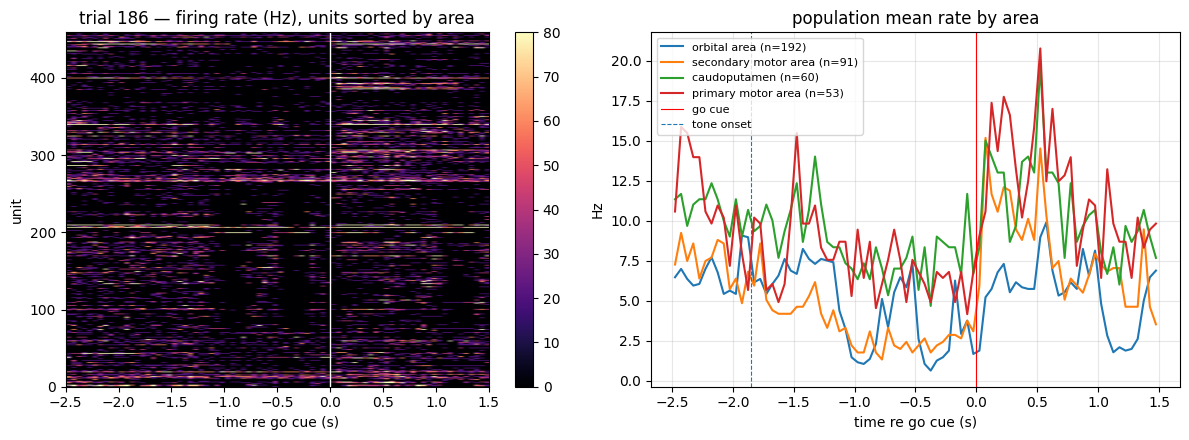

In [35]:
order = np.argsort(regions)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
im = ax[0].imshow(X[order], aspect='auto', origin='lower', cmap='magma',
                  extent=[-2.5, 1.5, 0, len(good)], vmax=np.percentile(X, 99))
ax[0].set(title='trial 186 — firing rate (Hz), units sorted by area',
          xlabel='time re go cue (s)', ylabel='unit')
ax[0].axvline(0, color='w', lw=1)
plt.colorbar(im, ax=ax[0])

for r in pd.Series(regions).value_counts().head(4).index:
    m = regions == r
    ax[1].plot(np.arange(-2.5, 1.5, 0.05) + 0.025, X[m].mean(0), label=f'{r} (n={m.sum()})')
ax[1].axvline(0, color='r', lw=0.8, label='go cue')
ax[1].axvline(-1.85, color='C0', lw=0.8, ls='--', label='tone onset')
ax[1].set(title='population mean rate by area', xlabel='time re go cue (s)', ylabel='Hz')
ax[1].legend(fontsize=8)
ax[1].grid(alpha=0.3)
plt.tight_layout()